In [104]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [105]:
df = pd.read_csv("train.csv", usecols=['Age', 'Fare', 'Survived'])

In [106]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [107]:
df.isnull().sum()*100

Survived        0
Age         17700
Fare            0
dtype: int64

In [108]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [109]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

In [110]:
X_train

,Age,Fare
331,45.5,28.5000
733,23.0,13.0000
382,32.0,7.9250
704,26.0,7.8542
813,6.0,31.2750
...,...,...
106,21.0,7.6500
270,NaN,31.0000
860,41.0,14.1083
435,14.0,120.0000


In [111]:
X_train['Age_impute'] = X_train['Age']
X_test['Age_impute'] = X_test['Age']

# X_train['Fare_impute'] = X_train['Fare']
# X_test['Fare_impute'] = X_test['Fare']

In [112]:
X_test.tail()

,Age,Fare,Age_impute
433,17.0,7.1250,17.0
773,NaN,7.2250,NaN
25,38.0,31.3875,38.0
84,17.0,10.5000,17.0
10,4.0,16.7000,4.0


In [113]:
X_train['Age_impute'][X_train['Age_impute'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
X_test['Age_impute'][X_test['Age_impute'].isnull()] = X_test['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

C:\Users\abdee\AppData\Local\Temp\ipykernel_13964\3992158056.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['Age_impute'][X_train['Age_impute'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
C:\

In [114]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([58. , 29. , 26. , 36. , 37. , 18. , 34. , 45. , 19. , 24. ,  7. ,
       18. , 23. , 27. ,  1. , 42. , 22. ,  8. , 45. , 32. , 27. , 22. ,
       21. , 18. , 33. , 20. , 22. , 15. ,  2. , 48. , 35. , 20. , 40. ,
       38. , 80. , 26. , 39. , 30. , 24. , 20. , 28. , 30. , 21. , 39. ,
       17. , 58. , 18. , 29. ,  2. , 36. , 32. , 18. , 33. , 34. , 28. ,
       32. , 60. , 20. , 42. , 25. , 27. , 31. ,  5. , 47. , 44. , 52. ,
       21. , 54. , 25. , 21. , 45. , 24. , 54. , 24. , 40. , 25. , 24. ,
       45. , 34. ,  4. , 22. , 28. , 54. , 27. , 19. , 45. , 24. , 14. ,
       26. , 24. , 25. , 49. , 33. , 34. , 24. , 21. , 31. , 17. , 30. ,
       30. ,  7. , 55. , 30. , 20. , 30. ,  4. , 42. ,  5. , 39. , 31. ,
       29. , 22. , 25. , 41. , 21. , 31. , 31. , 35. , 32. , 70.5, 56. ,
       42. , 32. ,  3. , 26. , 62. ,  1. , 46. , 50. , 31. ,  2. , 40. ,
       32. , 23. , 20. , 22. , 45.5, 25. , 24. ,  4. ])

In [115]:
X_train['Age'].isnull().sum()

np.int64(140)

In [116]:
X_train

,Age,Fare,Age_impute
331,45.5,28.5000,45.5
733,23.0,13.0000,23.0
382,32.0,7.9250,32.0
704,26.0,7.8542,26.0
813,6.0,31.2750,6.0
...,...,...,...
106,21.0,7.6500,21.0
270,NaN,31.0000,14.0
860,41.0,14.1083,41.0
435,14.0,120.0000,14.0


C:\Users\abdee\AppData\Local\Temp\ipykernel_13964\137691505.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'],label='Original',hist=False)
C:\Users\abdee\AppData\Local\Temp\ipykernel_13964\137691505.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['A

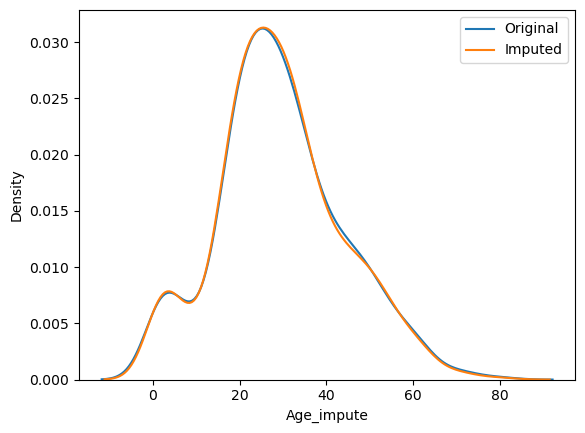

In [117]:
sns.distplot(X_train['Age'],label='Original',hist=False)
sns.distplot(X_train['Age_impute'],label='Imputed',hist=False)

plt.legend()
plt.show()

In [118]:
print('Original variable variance : ', X_train['Age'].var())
print('Variance after random imputation : ', X_train['Age_impute'].var())
      

Original variable variance :  210.2517072477438
Variance after random imputation :  205.55837215960275


In [119]:
X_train[['Fare', 'Age', 'Age_impute']].cov()

,Fare,Age,Age_impute
Fare,2700.831981,71.580633,62.756873
Age,71.580633,210.251707,210.251707
Age_impute,62.756873,210.251707,205.558372


<Axes: >

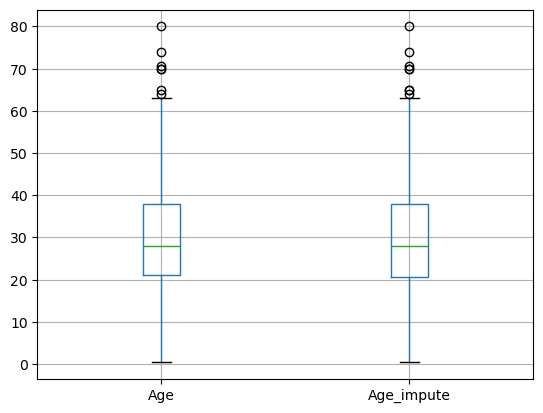

In [120]:
X_train[['Age', 'Age_impute']].boxplot()

In [121]:
sample_value = X_train['Age'].dropna().sample(1, random_state=int(observation=['Fare']))

TypeError: int() got an unexpected keyword argument 'observation'

In [123]:
data = pd.read_csv('house-train.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])

In [125]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [126]:
data.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [127]:
X = data
y = data['SalePrice']

In [128]:
X_train, X_test, y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [132]:
X_train

,FireplaceQu,GarageQual,SalePrice
254,NaN,TA,145000
1066,TA,TA,178000
638,NaN,NaN,85000
799,TA,TA,175000
380,Gd,TA,127000
...,...,...,...
1095,Gd,TA,176432
1130,TA,TA,135000
1294,NaN,TA,115000
860,Gd,TA,189950


In [135]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FirePlaceQU_imputed'] = X_train['FireplaceQu']
X_test['FirePlaceQU_imputed'] = X_test['FireplaceQu']

In [136]:
X_train.tail()

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FirePlaceQU_imputed
1095,Gd,TA,176432,TA,Gd
1130,TA,TA,135000,TA,TA
1294,NaN,TA,115000,TA,NaN
860,Gd,TA,189950,TA,Gd
1126,TA,TA,174000,TA,TA


In [138]:
X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

X_train['FirePlaceQU_imputed'][X_train['FirePlaceQU_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
X_test['FirePlaceQU_imputed'][X_test['FirePlaceQU_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

C:\Users\abdee\AppData\Local\Temp\ipykernel_13964\3780826686.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQua

In [142]:
temp = pd.concat(
    [
        X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
        X_train['GarageQual_imputed'].value_counts() / len(X_train)
    ],
    axis=1)

temp.columns = ['Original', 'Imputed']

In [143]:
temp

,Original,Imputed
TA,0.951087,0.952055
Fa,0.032609,0.032534
Gd,0.011775,0.011130
Ex,0.002717,0.002568
Po,0.001812,0.001712


In [146]:
temp = pd.concat(
        [
            X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
            X_train['FirePlaceQU_imputed'].value_counts() / len(df)
        ],
        axis=1)

temp.columns = ['Original', 'Imputed']

In [147]:
temp

,Original,Imputed
Gd,0.491143,0.639731
TA,0.405797,0.539843
Fa,0.043478,0.054994
Ex,0.033816,0.044893
Po,0.025765,0.031425


C:\Users\abdee\AppData\Local\Temp\ipykernel_13964\2695486330.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
C:\Users\abdee\AppData\Local\Temp\ipykernel_13964\2695486330.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457a

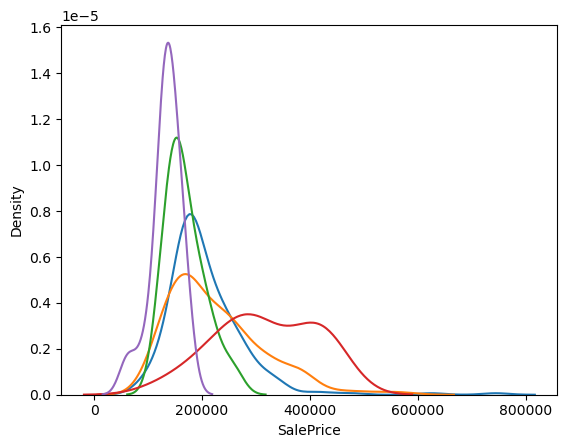

In [157]:

for category in X_train['FireplaceQu'].dropna().unique():
    sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
plt.show()

C:\Users\abdee\AppData\Local\Temp\ipykernel_13964\3509367330.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FirePlaceQU_imputed'] == category]['SalePrice'],hist=False,label=category)
C:\Users\abdee\AppData\Local\Temp\ipykernel_13964\3509367330.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed

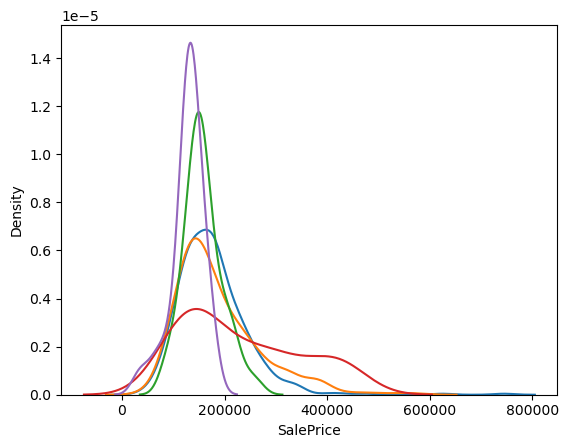

In [161]:
for category in X_train['FirePlaceQU_imputed'].dropna().unique():
    sns.distplot(X_train[X_train['FirePlaceQU_imputed'] == category]['SalePrice'],hist=False,label=category)
plt.show()